# Question:What is the overall sentiment of Fed and inflation news over time?"

# Cell 1 — config & imports

In [8]:
# Cell 1 — config & imports
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datetime import datetime, timedelta
import time
from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv("NEWS_API_KEY")
TOPIC = '"Federal Reserve" AND ("interest rates" OR inflation)'
DAYS_BACK = 27  # free tier allows up to 30

## Cell 2 - Fetch headlines (day by day to ensure full coverage)

In [12]:
def fetch_headlines(topic, api_key, days_back=27):
    headlines = []
    url = "https://newsapi.org/v2/everything"
    now = datetime.now()

    for day_offset in range(days_back, 0, -1):
        day = now - timedelta(days=day_offset)
        day_str = day.strftime("%Y-%m-%d")

        params = {
            "q": topic,
            "from": day_str,
            "to": day_str,
            "language": "en",
            "sortBy": "publishedAt",
            "pageSize": 100,
            "apiKey": api_key,
        }

        response = requests.get(url, params=params)
        data = response.json()

        if data["status"] != "ok":
            print(f"Error on {day_str}:", data.get("message"))
            continue

        count = len(data["articles"])
        for article in data["articles"]:
            headlines.append({
                "title": article["title"],
                "published": article["publishedAt"][:10],
                "source": article["source"]["name"],
                "url": article["url"],
            })

        print(f"{day_str} — {count} articles")
        time.sleep(0.5)  # stay under rate limit

    print(f"\nTotal: {len(headlines)} headlines")
    return pd.DataFrame(headlines).drop_duplicates(subset="url")

df = fetch_headlines(TOPIC, API_KEY, DAYS_BACK)
df.head(10)

2026-03-01 — 11 articles
2026-03-02 — 60 articles
2026-03-03 — 55 articles
2026-03-04 — 46 articles
2026-03-05 — 66 articles
2026-03-06 — 85 articles
2026-03-07 — 27 articles
2026-03-08 — 18 articles
2026-03-09 — 81 articles
2026-03-10 — 48 articles
2026-03-11 — 49 articles
2026-03-12 — 50 articles
2026-03-13 — 88 articles
2026-03-14 — 19 articles
2026-03-15 — 16 articles
2026-03-16 — 56 articles
2026-03-17 — 56 articles
2026-03-18 — 96 articles
2026-03-19 — 95 articles
2026-03-20 — 76 articles
2026-03-21 — 18 articles
2026-03-22 — 11 articles
2026-03-23 — 71 articles
2026-03-24 — 62 articles
2026-03-25 — 49 articles
2026-03-26 — 61 articles
2026-03-27 — 52 articles

Total: 1422 headlines


,title,published,source,url
0,Oil prices spike 9% and stock futures tumble i...,2026-03-01,Business Insider,https://www.businessinsider.com/oil-prices-ira...
1,NBA star’s partnership with a prediction marke...,2026-03-01,Fortune,https://fortune.com/2026/03/01/giannis-antetok...
2,"Live: Iran strikes set to rattle markets, oil ...",2026-03-01,ABC News (AU),https://www.abc.net.au/news/2026-03-02/asx-mar...
3,Trump expects his Fed pick and AI to deliver a...,2026-03-01,The Times of India,https://economictimes.indiatimes.com/news/inte...
4,"The Fed: If You’re Thinking About It, Your Min...",2026-03-01,Forbes,https://www.forbes.com/sites/johntamny/2026/03...
5,"Trump expects Fed pick, AI to bring replay of ...",2026-03-01,Abcnews.com,https://abcnews.com/Business/wireStory/trump-e...
6,Your grandparents are the reason the U.S. isn’...,2026-03-01,Fortune,https://fortune.com/2026/03/01/boomer-consumpt...
7,"Gold Surges Past $5,200 as Geopolitical Risks ...",2026-03-01,Ibtimes.com.au,https://www.ibtimes.com.au/gold-surges-past-52...
8,Stephen Moore: Cutting Government Spending Is ...,2026-03-01,Breitbart News,https://www.breitbart.com/clips/2026/02/28/ste...
9,Cliff Taylor: Trump’s economic moves seem cont...,2026-03-01,The Irish Times,https://www.irishtimes.com/opinion/2026/03/01/...


# Cell 3 — score sentiment with VADER

In [13]:
analyzer = SentimentIntensityAnalyzer()

def score_headline(title):
    scores = analyzer.polarity_scores(str(title))
    return scores["compound"]  # -1.0 (very negative) to +1.0 (very positive)

df["sentiment"] = df["title"].apply(score_headline)

# label for readability
def label(score):
    if score >= 0.05:  return "positive"
    elif score <= -0.05: return "negative"
    else: return "neutral"

df["label"] = df["sentiment"].apply(label)
df[["title", "sentiment", "label"]].head(10)

,title,sentiment,label
0,Oil prices spike 9% and stock futures tumble i...,-0.4404,negative
1,NBA star’s partnership with a prediction marke...,-0.4588,negative
2,"Live: Iran strikes set to rattle markets, oil ...",-0.4019,negative
3,Trump expects his Fed pick and AI to deliver a...,-0.2960,negative
4,"The Fed: If You’re Thinking About It, Your Min...",0.0000,neutral
5,"Trump expects Fed pick, AI to bring replay of ...",-0.2960,negative
6,Your grandparents are the reason the U.S. isn’...,-0.4215,negative
7,"Gold Surges Past $5,200 as Geopolitical Risks ...",-0.5423,negative
8,Stephen Moore: Cutting Government Spending Is ...,0.1280,positive
9,Cliff Taylor: Trump’s economic moves seem cont...,-0.4118,negative


# Cell 4 — aggregate by day

In [14]:
daily = (
    df.groupby("published")
    .agg(
        avg_sentiment=("sentiment", "mean"),
        article_count=("title", "count"),
        positive=("label", lambda x: (x == "positive").sum()),
        negative=("label", lambda x: (x == "negative").sum()),
        neutral=("label",  lambda x: (x == "neutral").sum()),
    )
    .reset_index()
)

daily["published"] = pd.to_datetime(daily["published"])
daily = daily.sort_values("published")
print(daily)

    published  avg_sentiment  article_count  positive  negative  neutral
0  2026-03-01      -0.312427             11         1         9        1
1  2026-03-02      -0.157115             60        15        34       11
2  2026-03-03      -0.206480             55        14        30       11
3  2026-03-04      -0.099430             46        13        20       13
4  2026-03-05      -0.216961             66        11        36       19
5  2026-03-06      -0.237435             85        17        51       17
6  2026-03-07      -0.273652             27         5        18        4
7  2026-03-08      -0.213094             18         2        10        6
8  2026-03-09      -0.208806             81        16        49       16
9  2026-03-10      -0.214925             48        11        24       13
10 2026-03-11      -0.179704             49         8        23       18
11 2026-03-12      -0.233346             50         7        33       10
12 2026-03-13      -0.188717             88        

In [ ]:
daily['published']

0   2026-03-03
1   2026-03-04
2   2026-03-10
3   2026-03-11
4   2026-03-18
5   2026-03-24
6   2026-03-25
Name: published, dtype: datetime64[ns]

# Cell 5 — plot it


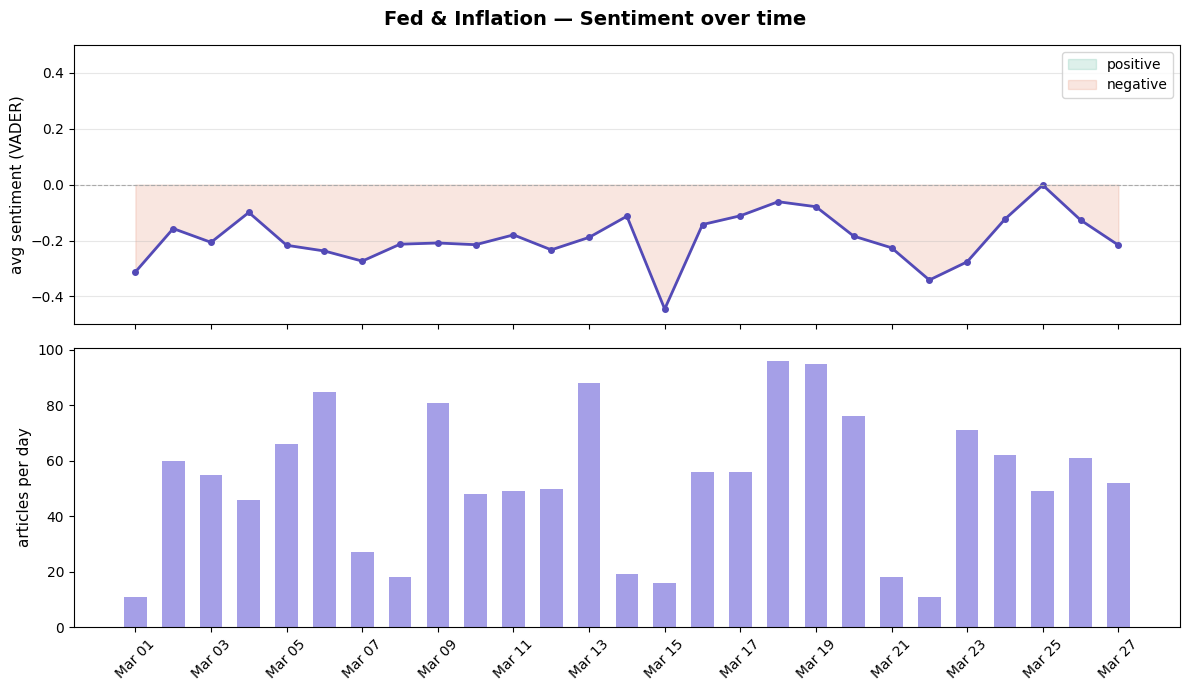

Chart saved as fed_sentiment.png


In [15]:
# Cell 5 — plot it
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Fed & Inflation — Sentiment over time", fontsize=14, fontweight="bold")

# --- top chart: sentiment line ---
ax1.plot(daily["published"], daily["avg_sentiment"], color="#534AB7", linewidth=2, marker="o", markersize=4)
ax1.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax1.fill_between(
    daily["published"], daily["avg_sentiment"], 0,
    where=(daily["avg_sentiment"] >= 0), color="#1D9E75", alpha=0.15, label="positive"
)
ax1.fill_between(
    daily["published"], daily["avg_sentiment"], 0,
    where=(daily["avg_sentiment"] < 0),  color="#D85A30", alpha=0.15, label="negative"
)
ax1.set_ylabel("avg sentiment (VADER)", fontsize=11)
ax1.set_ylim(-0.5, 0.5)
ax1.legend(fontsize=10)
ax1.grid(axis="y", alpha=0.3)

# --- bottom chart: volume bars ---
ax2.bar(daily["published"], daily["article_count"], color="#7F77DD", alpha=0.7, width=0.6)
ax2.set_ylabel("articles per day", fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("fed_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as fed_sentiment.png")